# Chapter 2 Problems

To have a good time when learning statistics,
you need to be fluent with probability calculations.
The best way to gain this fluency is to solve lots of problems.
Reading is not enough---you need to get hands-on experience with probability distributions
so you'll know how to compute probabilities and expectations.
How convenient is it that the next pages contain a bunch of practice problems
to test your understanding of the probability theory concepts that we covered in this chapter?
Grab a coffee and dive in!

#### Notebook setup

In [1]:
# load Python modules
import os
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (5, 2)},
)
%config InlineBackend.figure_format = 'retina'

In [3]:
# Set pandas precision
pd.set_option("display.precision", 2)

In [4]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


### P2.1 

Explain in your own words why the CDF $F_X$
contains the same information as the probability distribution $f_X$.
How do you get $f_X$ from $F_X$?
Make sure your explanation works whether $X$ is discrete or continuous.

Hint: You may need to produce two separate explanations.

<!-- @solution -->
**Solution** 
The CDF $F_X(b)$ computes the probability $\textrm{Pr}(\{X \leq b\})$.
We obtain the same information from the probability function $f_X$
using summation when $X$ is discrete,
or integration when $X$ is continuous.
We can get $f_X$ from $F_X$
by calculating the "changes" in $F_X$.
In the discrete case,
we compute $f_X$ using the jumps in the CDF:
$f_X(x) = F_X(x) - F(x^{-})$,
where $x^{-}$ is the value immediately preceding $x$.
In the continuous case,
we use differentiation $f_X(x) = \frac{d}{dx} F_X(x)$.

### P2.2

The *addition rule* of probability states that
$$\textrm{Pr}(A \cup B) = \textrm{Pr}(A) + \textrm{Pr}(B) - \textrm{Pr}(A \cap B),$$
for any two events $A$ and $B$.
The symbol $\cup$ describes the *union* of two sets,
which means all elements that are either in $A$ or in $B$,
or in both.
The symbol $\cap$ describes the *intersection* of the two sets,
meaning the elements that are both in $A$ and in $B$.
Apply the addition rule to the die roll random variable $D$,
for the events $A = \{1,2,3\}$ and $B = \{2,3,4\}$,
by computing the probabilities of all terms in the above equation
and checking that the equality holds.

In [6]:
# @studentprompt
A = {1,2,3}
B = {2,3,4}

# Function that calculates the probability of event E (a set)
def Pr(E):
    ...


<!-- @solution -->
**Solution** 
Given the sets $A = \{1,2,3\}$ and $B = \{2,3,4\}$,
their union is $A \cup B = \{1,2,3,4\}$
and their intersection is $A \cap B = \{2,3\}$.
To verify the addition rule $\textrm{Pr}(A \cup B) = \textrm{Pr}(A) + \textrm{Pr}(B) - \textrm{Pr}(A \cap B)$,
we'll compute the probabilities of all the terms in the equation:
$\textrm{Pr}(\{1,2,3,4\}) = \tfrac{4}{6}$,
$\textrm{Pr}(\{1,2,3\}) = \tfrac{3}{6}$,
$\textrm{Pr}(\{2,3,4\}) = \tfrac{3}{6}$,
and $\textrm{Pr}(\{2,3\}) = \tfrac{2}{6}$.
Plugging these values into the equation,
we get $\tfrac{4}{6} = \tfrac{3}{6} + \tfrac{3}{6} - \tfrac{2}{6}$,
which verifies the addition rule in this example.
Intuitively,
the addition rule tells us
that we can compute $\textrm{Pr}(A \cup B)$
by adding $\textrm{Pr}(A)$ and $\textrm{Pr}(B)$
then subtracting $\textrm{Pr}(A \cap B)$
to avoid double-counting the probabilities of the common outcomes.

In [7]:
# @solution
A = {1,2,3}
B = {2,3,4}

# Function that calculates the probability of event E (a set)
def Pr(E):
    return sum([1/6 for outcome in E])

# Compute the left and right sides of the equation
Pr(A.union(B)), Pr(A) + Pr(B) - Pr(A.intersection(B)) 

(0.6666666666666666, 0.6666666666666667)

### P2.3

Explain the link between the Poisson random variable $H\!\sim\!{\mathrm{Pois}(\lambda\!=\!20)}$
and the exponential random variable $E \sim \mathrm{Expon}(\lambda\!=\!20)$
in the context of the hard disk example
where $H$ counts the hard disk failures in one month.

<!-- @solution -->
**Solution** 
The exponential random variable $E \sim \mathrm{Expon}(\lambda\!=\!20)$
describes the waiting time until the next hard disk failure,
where time is measured in months.
Both variables arise from the same Poisson process:
$H$ counts failures during one month,
whereas $E$ measures the waiting time to the next failure.

<!-- @solution -->
The Poisson probability $\Pr(H=0)$ is the probability of getting $0$ counts in unit time. The complement exponential CDF evaluated at unit time gives the same quantity.

In [8]:
# @solution
from scipy.stats import expon, poisson
lam = 20
rvH = poisson(mu=lam)
rvE = expon(loc=0, scale=1/lam)
rvH.pmf(0), 1.0 - rvE.cdf(1)

(2.061153622438558e-09, 2.0611535811454473e-09)

More generally,
if $N(t)$ counts failures during an interval of length $t$ months,
then $\textrm{Pr}(\{E > t\}) = \textrm{Pr}(\{N(t)=0\}) = e^{-20t}$.

### P2.4  
<!-- {prob:kombucha-sampling-dist-mean-n20} -->

Recall the probability distribution $K \sim \mathcal{N}(1000,10)$
that describes the kombucha volume in individual bottles.
Define the sampling distribution of the mean
$\overline{\mathbf{K}} \sim \mathcal{N}\big(\mu_{\overline{\mathbf{K}}}, \sigma_{\overline{\mathbf{K}}}\big)$
for samples of size $n=20$ from the population.

**a)** Plot the PDF of the random variable $K \sim \mathcal{N}(1000,10)$.

**b)** Calculate $\mu_{\overline{\mathbf{K}}}$ and $\sigma_{\overline{\mathbf{K}}}$
using the formula for the sampling distribution of the mean
from the central limit theorem stated on page .

**c)** Plot the PDF of the random variable $\overline{\mathbf{K}}$.

**d)** Explain the difference between the distributions $K$ and $\overline{\mathbf{K}}$.

In [9]:
# @studentprompt
from scipy.stats import norm

# Kombucha population
rvK = ...

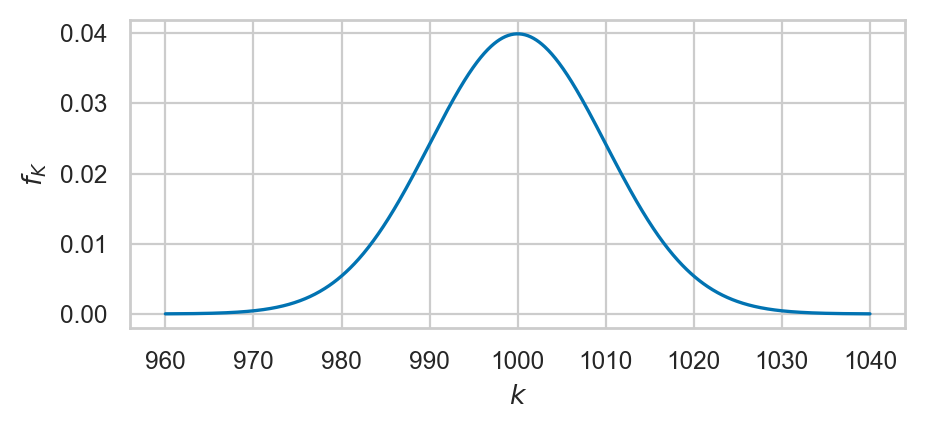

In [10]:
# @solution
from scipy.stats import norm

# Kombucha population
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

# a) Plot the PDF
from ministats import plot_pdf
plot_pdf(rvK, xlims=[960,1040], rv_name="K");

In [11]:
# @solution
# b) Parameters of the sampling distribution of the mean
muKbar = muK
sigmaKbar = sigmaK / np.sqrt(20)
sigmaKbar

2.23606797749979

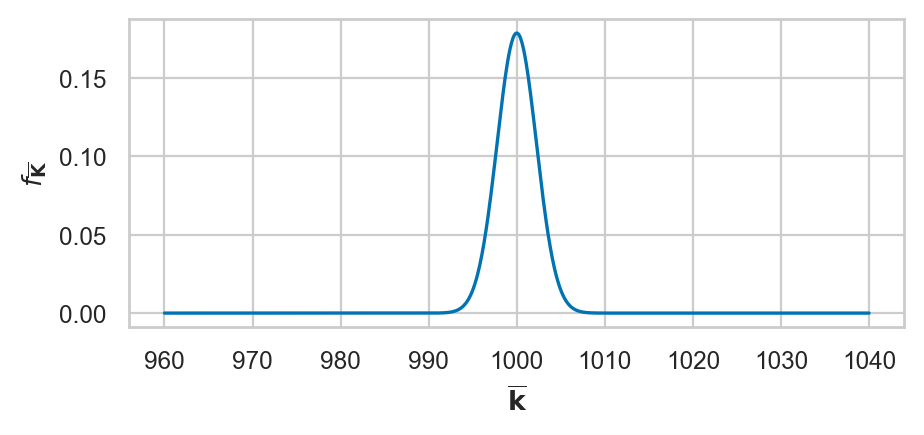

In [12]:
# @solution
# c) Plot the sampling distribution of the mean
rvKbar = norm(muKbar, sigmaKbar)
plot_pdf(rvKbar, xlims=[960,1040], rv_name=r"\overline{\mathbf{K}}");

<!-- @solution -->
**d)** 
The random variable $K$ describes the volume of one randomly selected bottle,
whereas $\overline{\mathbf{K}}$ describes the mean volume of $20$ randomly selected bottles.
Both distributions are normal and have the same centre,
$\mu_K=\mu_{\overline{\mathbf{K}}}=1000$,
but the sampling distribution of the mean is narrower by a factor of $\sqrt{20}$.

### P2.5
<!-- {problem:kombucha-empirical-dist-calculations} -->

When we have the complete data from a population,
we can use the empirical distribution of the data to do probability calculations.
Load the 1000 observations from Batch 55 from the dataset
[`datasets/kombuchapop.csv`](https://noBSstats.com/datasets/kombuchapop.csv)
and compute the probability that a bottle contains at least $1005$ml.

In [13]:
import pandas as pd
kombuchapop = pd.read_csv("https://noBSstats.com/datasets/kombuchapop.csv")
kpop55 = kombuchapop[kombuchapop["batch"]==55]["volume"]
kpop55

0       968.84
1       971.92
2       973.13
3       974.78
4       975.71
        ...   
995    1025.91
996    1028.00
997    1032.58
998    1032.73
999    1047.87
Name: volume, Length: 1000, dtype: float64

In [14]:
# @studentprompt
# Compute the proportion of values >= 1005 in kpop55


<!-- @solution -->
We're interested in the probability $\textrm{Pr}(\{K \geq 1005\})$,
where $K$ is represented empirically as the list of $1000$ observations from Batch 55.
To compute this probability,
we can calculate the proportion of observations that are greater than or equal to $1005$:

In [15]:
# @solution
# Compute the proportion of values >= 1005 in kpop55
len([k for k in kpop55 if k >= 1005]) / len(kpop55)

0.32

### P2.6 

Consider the random variable $X$ with three possible outcomes $\{1,2,3\}$
and probability mass function $f_X = [p_1,p_2,p_3]$.
Prove that $p_1 \leq 1$.

Hint: Use Kolmogorov's axioms to build a proof by contradiction.

<!-- @solution -->
**Solution** 
Assume, for a contradiction, that $p_1 >1$.
Kolmogorov's first axiom tells us that $p_i \geq 0$,
for all $i$.
This means that $p_1 + p_2 + p_3 \geq p_1$,
since $p_2 \geq 0$ and $p_3 \geq 0$.
Kolmogorov's second axiom tells us that $\sum_{i=1}^3 p_i = 1$.
Observe that $\sum_{i=1}^3 p_i \geq p_1 >1$.
This means that $[p_1,p_2,p_3]$ is not a valid PMF.
We assumed $p_1 >1$ and reached a contradiction.
Therefore,
it must be that $p_1 > 1$ is false, and $p_1 \leq 1$ is true.

### P2.7
The probability of `heads` for a fair coin is $p=\frac{1}{2}$.
What is the probability of getting `heads` four times in a row
in four independent tosses?

<!-- @solution -->
**Solution** 
The probability of getting `heads` $n$ times in a row is given by the expression $p^n$.
We substitute $p=\frac{1}{2}$ and $n=4$ into this expression to get $(\frac{1}{2})^4 = \frac{1}{16}$.

### P2.8
<!-- {problem:geometric_distr_biased_coin_until_heads} -->

You have a biased coin that lands on `heads` with probability $p$,
and on `tails` with probability $1-p$.
Suppose you want to flip the coin until you get `heads`.
Define the random variable $G$ as the number of tosses
required until the first `heads` outcome.
What is the probability mass function $f_G(k)$ for the first success on the $k$^th^ toss?
Confirm that the formula is a valid probability distribution by showing $\sum_{k=1}^\infty f_G(k) = 1$.

Hint: Find the probabilities for cases $k=1,2,3,\ldots$ and look for a pattern.


<!-- @solution -->
**Solution** 
The biased coin flip is modelled by a random variable $Y$,
and different coin flips correspond to random variables $Y_1$, $Y_2$, $Y_3$, ...,
which are independent copies of $Y$.
The probability of getting `heads` on the first flip is
$f_G(1)=\textrm{Pr}\!\left( \{ Y_1=\texttt{heads} \} \right)\! = p$.
The probability of getting the first `heads` on the second flip corresponds
to the event $\{Y_1=\texttt{tails}\} \ \texttt{AND} \ \{Y_2=\texttt{heads} \}$.
We assumed the coin flips are independent, so
$f_G(2)=(1-p)p$.
Similarly $f_G(3) = (1-p)^2p$.
The general formula is $f_G(k) = (1-p)^{k-1}p$,
which is the PMF of the geometric distribution $G \sim \mathrm{Geom}(p)$.

### P2.9

A mathematician walks over to a roulette table in a casino.
The roulette wheel has 101 numbers:
50 are black,
50 are red,
and the number zero is green.
If the mathematician bets $\$1$ on black and the roulette ball stops on a black number,
the payout is $\$2$, otherwise the bet is lost.
The same payout rule applies to bets placed on red.
Calculate the expected payout from playing this game,
and determine whether it's worth playing it.

<!-- @solution -->
**Solution** 
We'll model each spin of the roulette wheel as a random variable $X$
with sample space $\{ \textrm{red}, \textrm{black}, \textrm{green}\}$
and probability distribution $f_X = (\frac{50}{101},\frac{50}{101},\frac{1}{101})$.
When placing a bet on black, the payout is $\$2$ if the outcome is black, and zero for other outcomes.
The expected payout of this game is
$\mathbb{E}_X[\text{game}(X)]=0\cdot \frac{50}{101} + \$2 \cdot \frac{50}{101} + 0\cdot \frac{1}{101}=\$\frac{100}{101}$.
The payout is less than the cost,
$\frac{100}{101} < 1$,
so the mathematician decides not to play.

$\newcommand\mydice[1]{#1}$
### P2.10

Consider the following variation of the six-sided die game.
You pay $\$1$ to play one round of the game and the payout for the game is as follows.
If you roll a $\mydice{1}$, a $\mydice{2}$, or a $\mydice{3}$, you win nothing.
If you roll a $\mydice{4}$ or a $\mydice{5}$, the payout is $\$1$.
If you roll a $\mydice{6}$, the payout is $\$5$.
Should you play this game?


In [16]:
# @studentprompt
from scipy.stats import randint

# Random variable that corresponds rolling a fair die
rvD = randint(1,6+1)


In [17]:
# @solution
# Random variable that corresponds rolling a fair die
from scipy.stats import randint
rvD = randint(1,6+1)

# The payout function for the game
def g(d):
    if d == 6:
        return 5
    elif d == 4 or d == 5:
        return 1
    else:
        return 0

# Compute the expected value of `g` for 
rvD.expect(np.vectorize(g))

1.1666666666666665

<!-- @solution -->
$\newcommand\mydice[1]{#1}$
**Solution** 
The payout function for this game is as follows:
$$g(\mydice{1}) = g(\mydice{2}) = g(\mydice{3}) = \$0,
              \quad
              g(\mydice{4}) = g(\mydice{5}) = \$1,
              \quad
              g(\mydice{6}) = \$5.$$
The die is described by the distribution
$f_D(d) = \frac{1}{6}$ for $d \in \{\mydice{1}, \mydice{2}, \mydice{3}, \mydice{4}, \mydice{5}, \mydice{6}\}$.
The expected payout is
$\mathbb{E}_D[g(D)]  
                = \textstyle \sum_d g(d)\, f_D(d)
                = \tfrac{\$1+\$1+\$5}{6}  \ = \  \tfrac{\$7}{6} \ = \ \$1.1\overline{6}$.
The expected payout is greater than the cost to play,
so this game is worth playing.


### P2.11
<!-- {problem:parallel-axis-thm} -->

The parallel axis theorem tells us
that the variance of a discrete random variable $X$ with distribution $f_X$
can be computed using the formula
$\mathbf{Var}(X) = \sum_{x\in \mathcal{X}} x^2\,f_X(x)  \ - \ \mu_{X}^2$.
Show that this formula is equivalent to the definition of the variance
$\mathbf{Var}(X) = \mathbb{E}_X\!\big[(X-\mu_{X})^2\big]$.

Hint: Start from the definition $\mathbf{Var}(X) = \mathbb{E}_X\big[(X-\mu_{X})^2\big]$ and simplify it.

<!-- @solution -->
**Solution** 
Starting from $\mathbf{Var}(X) = \sum_x (x-\mu_{X})^2 \, f_X(x)$ and expanding the bracket,
we obtain
$$\sum_x \big( x^2  \, f_X(x)  - 2x\mu_{X}\, f_X(x) + \mu_{X}^2\,f_X(x) \big).$$

Since $\sum_x x\,f_X(x) = \mu_{X}$ and $\sum_x f_X(x) = 1$,
this variance expression simplifies to $\sum_x x^2\,f_X(x)  - \mu_{X}^2$.

### P2.12
<!-- {problem:pdf-2-minus-abs-y} -->
The continuous random variable $Y$
has probability density function $f_Y(y) = m(2 - |y|)$,
defined for $y \in [-2,2]$.
The constant $m$ is unknown.
Find the value of the constant $m$
that makes $f_Y$ a valid PDF.

Hint: We must choose the constant $m$
that makes the total area under the graph of $f_Y(y) = m(2 - |y|)$
equal to $1$.

<!-- @solution -->
**Solution** 
We start by sketching the graph of $f_Y(y) = m(2 - |y|)$
on the interval $y \in [-2,2]$.
The area under the graph of $f_Y$
consists of two triangles with base $2$ and height $2m$.
The area of each triangle is $\frac{1}{2}(2)(2m)$,
so the total area is $2(\frac{1}{2}(2)(2m))=4m$.
Choosing $m=\frac{1}{4}$
makes $f_Y$ a valid PDF that satisfies Kolmogorov's unit-total axiom.

### P2.13
<!-- {prob:markov-inequality-example} -->
The Markov inequality in probability theory
states that for any nonnegative random variable $X$,
we have
$$\textrm{Pr}(\{X \geq a\})
            \leq
            \frac{\mathbb{E}[X]}{a},
            \qquad
            \text{for all } a > 0.$$
Check that this inequality holds for the exponential random variable $E \sim \mathrm{Expon}(\lambda=3)$
in the case when $a = 1$.

**a)** Use Markov's inequality to find an upper bound for $\textrm{Pr}(\{E \geq 1\})$.

**b)** Calculate the exact value of the probability $\textrm{Pr}(\{E \geq 1\})$.

**c)** Compare the bound from part **a)** and the true probability from part **b)**.
Is Markov's inequality tight or loose in this example?

In [18]:
from scipy.stats import expon
rvE = expon(loc=0, scale=1/3)

<!-- @solution -->
**Solution** 
For $E \sim \mathrm{Expon}(\lambda=3)$,
we have $\mathbb{E}_E[E]=\frac{1}{3}$.
We apply Markov's inequality with $a=1$
to get $\textrm{Pr}(\{E \geq 1\}) \leq \frac{\mathbb{E}[E]}{1} = \frac{1}{3}$.
The true probability is $\textrm{Pr}(\{E \geq 1\}) = 1-F_E(1) = e^{-3} =0.0498$.
We see Markov's inequality gives the upper bound $\textrm{Pr}(\{E \geq 1\}) \leq 0.3333$
which is valid, but very loose compared to the true probability $0.0498$.

In [19]:
# @solution
# a) 
rvE.mean() / 1

0.3333333333333333

In [20]:
# @solution
# b) 
1 - rvE.cdf(1)

0.04978706836786395

In [21]:
# @solution
# c) Check Markov's inequality
1 - rvE.cdf(1) <= rvE.mean() / 1

True

### P2.14
<!-- {prob:chebyshev-inequality-example} -->
The Chebyshev inequality in probability theory
states that for any random variable $X$ with finite mean $\mu_X$
and finite standard deviation $\sigma_X$,
the following bound holds:
$$\textrm{Pr}(\{|X-\mu_X| \geq k\sigma_X\})
            \leq
            \frac{1}{k^2},
            \qquad
            \text{for all } k>0.$$
Apply this inequality to the random variable $E \sim \mathrm{Expon}(\lambda=3)$ and $k=2$.

**a)** Use Chebyshev's inequality to obtain an upper bound for the probability $\textrm{Pr}(\{|E-\mu_E| \geq 2\sigma_E\})$.

**b)** Calculate the exact value of the probability $\textrm{Pr}(\{|E-\mu_E| \geq 2\sigma_E\})$.

**c)** Compare the bound from part **a)** and the true probability from part **b)**.
Is Chebyshev's inequality tight or loose in this example?


In [22]:
from scipy.stats import expon
rvE = expon(loc=0, scale=1/3)


<!-- @solution -->
**Solution** 
For $E \sim \mathrm{Expon}(\lambda=3)$,
we have $\mu_E = \frac{1}{3}$ and $\sigma_E = \frac{1}{3}$.
For part **a)**,
we plug $\mu_E$ and $\sigma_E$ into Chebyshev's inequality with $k=2$
to obtain
$$\textrm{Pr}(\{|E-\mu_E| \geq 2\sigma_E\})   \leq \frac{1}{2^2}.$$
The event $\{ |E-\mu_E| \geq 2\sigma_E\} = \{ |E-\frac{1}{3}| \geq \frac{2}{3}\}$
can be split into two parts:
$\{E \geq 1\}$ and $\{E \leq -\frac{1}{3}\}$,
but the exponential random variable is nonnegative $E \geq 0$,
so the second part has zero probability.
The only part that remains is $\{E \geq 1\}$,
so the event $\{|E-\mu_E| \geq 2\sigma_E\}$
simplifies to $\{E \geq 1\}$,
and Chebyshev's inequality gives us $\textrm{Pr}(\{|E-\mu_E| \geq 2\sigma_E\}) \leq 0.25$.
For part **b)**,
we can calculate the exact value
from the CDF $F_E$:
$\textrm{Pr}(\{|E-\mu_E| \geq 2\sigma_E\}) = \textrm{Pr}(\{E \geq 1\}) = 1-F_E(1) = e^{-3} = 0.0498$.
The upper bound $\frac{1}{4}$ from Chebyshev's inequality
is loose compared to the exact probability $0.0498$.

In [23]:
# @solution
# a) 
1 / 2**2

0.25

In [24]:
# @solution
# b)
1 - rvE.cdf(1)

0.04978706836786395

In [25]:
# @solution
# c) Check Chebyshev's inequality
1 - rvE.cdf(1) <= 1 / 2**2

True

$\newcommand{\stderrhat}[1]{\widehat{\mathbf{se}}_{#1}}$
### P2.15
<!-- {problem:pT-vs-pZ-in-tails} -->
Zach and Tina are arguing about which probability distribution
to use to interpret the result of a statistical test.
The observed sample has size $n=31$,
sample mean $\overline{\mathbf{x}} = 90$,
and sample standard deviation $s_{\mathbf{x}} = 27.8388$.
The goal is to compare the observed sample mean to
the theoretical population mean $\mu_X = 100$.
The first step of applying the *one-sample $t$-test*
is to compute the estimated standard error
$\stderrhat{\overline{\mathbf{x}}} = \frac{ s_{\mathbf{x}} }{ \sqrt{31} } = 5$
and the $t$-statistic $\frac{\overline{\mathbf{x}} - \mu_X}{ \stderrhat{\overline{\mathbf{x}}} } = -2$.
Next we need to calculate the $p$-value
for the test,
which is the probability of observing $t$-statistic $-2$ or more extreme
under the sampling distribution relevant for this scenario.
Tina wants to use Student's $t$-distribution with $\nu = n-1 = 30$ degrees
of freedom to calculate the probability as follows:
$p_T = \textrm{Pr}(\{T \leq -2\} \cup \{T \geq 2\}) = F_{T_{30}}(-2) + (1 - F_{T_{30}}(2))$,
where $T_{30} \sim \mathcal{T}(\nu=30)$.
Zach learned from a YouTube video that, for $n > 30$,
the difference between the $t$-distribution
and the standard normal $Z$ is negligible,
so he wants to calculate the $p$-value using the $Z \sim \mathcal{N}(0,1)$.
His calculation of the $p$-value is
$p_Z = \textrm{Pr}(\{Z \leq -2\} \cup \{Z \geq 2\}) = F_{Z}(-2) + (1 - F_{Z}(2))$.
Zach is saying that $p_Z$ and $p_T$ are not that different,
so we don't need to be bothered with all the $T_{30} \sim \mathcal{T}(\nu=30)$ nonsense.
Compute the values $p_Z$ and $p_T$
and the relative difference $(p_T-p_Z)/p_Z$.
Is the difference really small like Zach claims?

In [26]:
xbar = 90
std = 27.8388
sehat = std / np.sqrt(31)

t = (xbar -  100) / sehat
t

-2.000001567176035

In [27]:
# @solution
from scipy.stats import norm

rvZ = norm(0,1)
pZ = rvZ.cdf(-2) + (1 - rvZ.cdf(2))
pZ

0.0455002638963584

In [28]:
# @solution
from scipy.stats import t as tdist

n = 31
df = n - 1
rvT = tdist(df=df)
pT = rvT.cdf(-2) + (1 - rvT.cdf(2))

print(f"{df=}  {pZ=:.5f}  {pT=:.5f}  percent diff. =", ((pT-pZ)/pZ*100).round(3) )

df=30  pZ=0.04550  pT=0.05463  percent diff. = 20.054


<!-- @solution -->
A difference of 20% is not "negligible" like Zach claims,
so we should use the $t$-distribution for the $t$-test
and not listen to random people on YouTube.

### P2.16
<!-- {problem:pT-vs-pZ-in-tails-different-n} -->
Repeat the calculations from
for sample sizes $n=51$, $n=101$, and $n=201$,
keeping the observed test statistic fixed at $t=-2$.


<!-- @solution -->
The calculations are the same as in the previous question,
but using Student's $t$-distribution with $\nu=50$, $\nu=100$, and $\nu=200$ degrees of freedom.

In [29]:
# @solution
from scipy.stats import norm
from scipy.stats import t as tdist

rvZ = norm(0,1)

for df in [50, 100, 200]:
    rvT = tdist(df=df)
    pZ = rvZ.cdf(-2) + (1 - rvZ.cdf(2))
    pT = rvT.cdf(-2) + (1 - rvT.cdf(2))
    print(f"{df=}\t{pZ=:.5f}  {pT=:.5f}  percent diff. =", ((pT-pZ)/pZ*100).round(3) , "%")

df=50	pZ=0.04550  pT=0.05095  percent diff. = 11.971 %
df=100	pZ=0.04550  pT=0.04821  percent diff. = 5.96 %
df=200	pZ=0.04550  pT=0.04685  percent diff. = 2.973 %


### P2.17
<!-- {binomial-variance-using-expectation-formulas} -->
Calculate the variance $\sigma_X^2$ of the binomial $X \sim \mathrm{Binom}(n,p)$.

Hint: The binomial $X$ is the sum of $n$ independent Bernoullis.

Hint: The variance of the distribution $B \sim \mathrm{Bernoulli}(p)$ is $p(1-p)$.

<!-- @solution -->
**Solution** 
The random variable $X \sim \mathrm{Binom}(n,p)$
is equivalent to the sum of $n$ independent Bernoulli random variables $B_i \sim \mathrm{Bernoulli}(p)$.
The variance of $X$ is $\sigma_X^2= \mathbf{Var}(X) = \mathbf{Var}(B_1 + B_2 + \cdots + B_n)$.
Using the properties of variance for independent random variables,
we get $\mathbf{Var}(B_1) + \mathbf{Var}(B_2) + \cdots + \mathbf{Var}(B_n) = n\mathbf{Var}(B)$.
We know that $\mathbf{Var}(B) = p(1-p)$,
so we can conclude that $\sigma_X^2 = \mathbf{Var}(X) = n\mathbf{Var}(B) = np(1-p)$.

### P2.18
<!-- {prob:discrete-uniform-mean-proof} -->
Calculate the mean of the discrete uniform variable $R \sim \mathcal{U}_d(\alpha,\beta)$.

Hint: The formula for the sum of the first $n$ integers is $\sum_{k=1}^n k = \frac{n(n+1)}{2}$.

Hint: Use the algebra formula $(a+b)(b-a+1) = b^2 -  a^2 + b + a$.

<!-- @solution -->
**Solution** 
Using the definition of expected value, we obtain
$$\mu_R
                    = \mathbb{E}_R[R]
                    = \sum_{r=\alpha}^{\beta} r \, \textrm{Pr}(\{R=r\})
                    = \sum_{r=\alpha}^{\beta} r \, \frac{1}{\beta-\alpha+1}
                    = \frac{1}{\beta-\alpha+1} \sum_{r=\alpha}^{\beta} r.$$
To calculate the summation $\sum_{r=\alpha}^{\beta} r$,
we can think of it as the sum from $r=1$ to $r=\beta$,
minus the sum from $r=1$ to $r=\alpha-1$,
then use the formula for the sum of the first $n$ integers twice
to compute these sums.
We end up with
$$\textstyle
                \sum_{r=\alpha}^{\beta} r
                    = \sum_{r=1}^{\beta} r - \sum_{r=1}^{\alpha-1} r
                    = \frac{\beta(\beta+1)}{2} - \frac{(\alpha-1)(\alpha)}{2}
                    = \frac{\beta^2 +\beta}{2} - \frac{\alpha^2-\alpha}{2}
                    = \frac{\beta^2 +\beta - \alpha^2 + \alpha}{2}.$$
We can use the second hint
to rewrite the expression in the numerator as $(\alpha+\beta)(\beta-\alpha+1)$.
We then put the expression $\sum_{r=\alpha}^{\beta} r$
back into the definition of $\mu_R$
to obtain the answer
$\mu_R = \mathbb{E}_R[R] 
                    = \frac{1}{\beta-\alpha+1}\frac{(\beta-\alpha+1)(\alpha+\beta)}{2}
                    = \frac{\alpha+\beta}{2}$.
:::

### P2.19
<!-- {prob:verify-U-var-discrete} -->
Calculate the variance of the discrete uniform variable $R \sim \mathcal{U}_d(\alpha,\beta)$.

Hint: Use the formulas
$\sum_{k=0}^{n-1} k = \frac{n(n-1)}{2}$
and $\sum_{k=0}^{n-1} k^2 = \frac{n(n-1)(2n-1)}{6}$.

<!-- @solution -->
**Solution** 
The mean is $\mu_R = \frac{\alpha+\beta}{2}$.
Let $N = \beta-\alpha+1$ denote the number of possible values in the sample space.
We start with the definition of the variance:
$$\sigma_R^2
                    = \mathbb{E}_R\left[(R-\mu_R)^2\right]
                    = \tfrac{1}{\beta-\alpha+1} \sum_{r=\alpha}^{\beta}
                               \!\left(r-\tfrac{\alpha+\beta}{2}\right)^{\!2}
                    = \tfrac{1}{N} \sum_{r=\alpha}^{\beta}
                               \!\left(r-\tfrac{\alpha+\beta}{2}\right)^{\!2}.$$
Next,
we change the summation index from $r$
to $j = r-\alpha$,
which varies from $j = 0$ to $j=N-1$.
The new indexing scheme
allows us to rewrite the sum as follows:
$$\tfrac{1}{N} \sum_{r=\alpha}^{\beta}
                               \left(r-\tfrac{\alpha+\beta}{2}\right)^{\!2}
                = \tfrac{1}{N}
                               \sum_{j=0}^{N-1}
                               \left(j-\tfrac{N-1}{2}\right)^{\!2}.$$
Expanding the square in the expression $\tfrac{1}{N} \sum_{j=0}^{N-1}  \left(j-\tfrac{N-1}{2}\right)^2$
gives us three terms:
$$\textstyle
                \frac{1}{N} \sum_{j=0}^{N-1}
                           \!\left[
                            j^2
                            -(N-1) j
                            +\tfrac{(N-1)^2}{4}
                           \!\right]
                    = \frac{1}{N} 
                           \!\left[
                            \sum_{j=0}^{N-1} j^2
                            -(N-1) \sum_{j=0}^{N-1} j
                            +\tfrac{(N-1)^2}{4} \sum_{j=0}^{N-1} 1 
                           \!\right]\!.$$
We can use the formulas $\sum_{j=0}^{N-1} j^2 = \frac{N(N-1)(2N-1)}{6}$
and $\sum_{j=0}^{N-1} j = \frac{N(N-1)}{2}$
to calculate the values of the first and second terms in the expanded sum.
The third term is a constant,
so it just gets multiplied by $N$.
We end up with
$$\sigma_R^2 = 
                    \tfrac{1}{N}\!\left[ \tfrac{N(N-1)(2N-1)}{6}
                                    -\tfrac{(N-1)^2N}{2}
                                    +\tfrac{N(N-1)^2}{4} \right]
                    = \tfrac{N^2-1}{12}
                    = \tfrac{(\beta-\alpha+1)^2-1}{12}.$$

### P2.20
<!-- {verify-U-var} -->
Find the variance of the continuous uniform variable $U \sim \mathcal{U}(\alpha,\beta)$.

Hint: Use the parallel axis theorem and the integral formula $\int x^2 \, dx = \frac{x^3}{3} + C$.


<!-- @solution -->
**Solution**
We know the mean is $\mathbb{E}_U[U] = \frac{\alpha+\beta}{2}$.
To calculate the variance,
we start from the parallel axis theorem,
and proceed step by step:

$$\begin{aligned}
    \sigma^2_U
        &= \mathbb{E}_U[U^2] - \mathbb{E}_U[U]^2
        = \int_\alpha^\beta \frac{x^2}{\beta-\alpha}dx - \frac{(\alpha+\beta)^2}{4} \\
        &= \frac{\beta^3 - \alpha^3}{3(\beta-\alpha)} - \frac{\alpha^2 + 2\alpha\beta + \beta^2}{4}
        = \frac{\beta^2 + \alpha\beta + \alpha^2}{3}- \frac{\alpha^2 + 2\alpha\beta + \beta^2}{4} \\
        &= \frac{4(\alpha^2 + \alpha\beta + \beta^2) - 3(\alpha^2 + 2\alpha\beta + \beta^2)}{12}
            = \frac{(\beta-\alpha)^2}{12}.
\end{aligned}$$

### P2.21
The odds of event $E$ occurring are given by the formula $p_E / (1-p_E)$.
You're told the odds of some event $A$ are $3$.
Find the probability $p_A$.

<!-- @solution -->
**Solution** 
We must solve the equation $3 = \frac{p_A}{1-p_A}$ for $p_A$.
We find that $p_A = 0.75$.

### P2.22
Consider the continuous random variables $X$ and $Y$
whose joint probability density function is $f_{XY}(x,y) = \frac{4}{5}(1+xy)$,
for all $(x,y)$ in the unit square
$\mathcal{D}_{XY} = [0,1] \times [0,1] = \{ (x,y) \in \mathbb{R}^2\,\vert\, x \in [0,1], y \in [0,1] \}$.
Compute the marginal distribution $f_Y$
and the conditional distribution $f_{X|Y}$.

<!-- @solution -->
**Solution** 
The marginal PDF of $Y$ is the integral of $f_{XY}$ over all $X$-values in $\mathcal{D}_{XY}$:
$$f_Y(y)  =  \int_0^1 f_{XY}(x,y)\,dx
                        =       \int_0^1 \tfrac{4}{5}(1+xy)\,dx
                        =       \tfrac{4}{5} \Big[ x + \tfrac{1}{2}yx^2 \Big]_0^1
                        =       \tfrac{4}{5}\!\left(1+\tfrac{y}{2}\right)\!.$$
This formula is valid for $y \in [0,1]$.
The conditional PDF of $X$ given $Y=y$ is
$f_{X|Y}(x|y)   =  \frac{f_{XY}(x,y)}{f_Y(y)}
                        =       \frac{\frac{4}{5}(1+xy)}{\frac{4}{5}\!\left(1+\frac{y}{2}\right)}
                        =       \frac{1+xy}{1+\frac{y}{2}}$,
which is valid for $x \in [0,1]$ and $y \in [0,1]$.

### P2.23

Suppose the continuous random variables $X$ and $Y$
have a joint probability density function:
$$f_{XY}(x,y) =
            \begin{cases}
                3(x+y),         & x \in [0,1],\; y \in [0,1-x], \\  % ALT. & x>0,\; y>0,\; x+y<1, \\
                0,              & \text{otherwise}.
            \end{cases}$$
Compute the marginal $f_X$
and the conditional $f_{Y|X}$ when $X=x$.

<!-- @solution -->
**Solution** 
The joint sample space $\mathcal{D}_{XY}$ has a triangular shape,
bounded by the $x$-axis from below,
the $y$-axis from the left,
and the line $x+y =1$ from above.
See Figure [\[fig:combined_joint_prob_triangle_fXY2\]](#fig:combined_joint_prob_triangle_fXY2){reference-type="ref" reference="fig:combined_joint_prob_triangle_fXY2"}
for an illustration of another distribution over the same sample space.
For a given value of $x$,
the outcomes of the variable $Y$ are constrained to the interval between $y=0$ and $y=1-x$.
We calculate the marginal $f_X$
by integrating $y$ on the interval $0 \leq y \leq 1-x$:
$$f_X(x)  =  \int_0^{1-x} \!\!\! 3(x+y)\,dy
                        =       3\!\left[xy+\tfrac{y^2}{2}\right]_{0}^{1-x} \!\!
                        =       3\!\left(x(1-x)+\tfrac{(1-x)^2}{2}\right)
                        =       \tfrac{3}{2}(1-x^2).$$
This formula is valid for $x \in [0,1]$.
The conditional probability density of $Y$ given $X\!=\!x$ is
$f_{Y|X}(y|x)   = \frac{f_{XY}(x,y)}{f_X(x)}
                = \frac{3(x+y)}{\frac{3}{2}(1-x^2)}
                = \frac{2(x+y)}{1-x^2}$,
for $x \in [0,1)$ and $y \in [0,1-x]$.

### P2.24

Given the random variables $X$ and $Y$ with joint probability density function:
$$f_{XY}(x,y) =
            \begin{cases}
                2(x+y),         & 0 \leq x \leq y \leq 1, \\
                0,              & \text{otherwise}.
            \end{cases}$$
Compute the marginal $f_X$ and the conditional $f_{Y|X}$ when $X=x$.

<!-- @solution -->
**Solution** 
The joint sample space $\mathcal{D}_{XY}$ has a triangular shape,
bounded by the diagonal line $y=x$ from below,
the $y$-axis from the left,
and the horizontal line at $y=1$ from above.
For a given value of $x$,
the outcomes of the variable $Y$ are constrained between the lines at $y=x$ and $y=1$.
We obtain the marginal $f_X$
by integrating $f_{XY}$ over $y \in [x,1]$:
$$f_X(x)  =   \int_x^1 \!\!\! 2(x+y)\,dy
                        =       2\!\left[xy+\tfrac{y^2}{2}\right]_{x}^{1} \!\!
                        =       2\!\left(x+\tfrac{1}{2} - x^2 - \tfrac{x^2}{2}\right)
                        =       1+2x-3x^2.$$
This formula is valid for $x \in [0,1]$.
The conditional PDF of $Y$ given $X=x$ is
$f_{Y|X}(y|x)
                = \frac{f_{XY}(x,y)}{f_X(x)}
                = \frac{2(x+y)}{1+2x-3x^2}$,
for $x \in [0,1)$ and $y \in [x,1]$.

### P2.25
<!-- {prob:high-specificity-diagnostic-test-S} -->
A diagnostic test is used to detect a virus.
Let's use $V \in \{0,1\}$
to indicate whether a patient has the virus or not.
We'll also use $S \in \{0,1\}$ to indicate the result of the test:
$S\!=\!1$ is positive and $S\!=\!0$ is negative.
The prevalence of the virus in the population is $f_V(1)=0.03$.
The test has sensitivity 90%, meaning $f_{S|V}(1|1)=0.9$.
The specificity of the test is 98%
which means $f_{S|V}(0|0)=0.98$
and the false positive rate is $f_{S|V}(1|0)=0.02$.

**a)** Compute the joint probabilities $f_{SV}(1,1)$ and $f_{SV}(1,0)$.

**b)** Compute the probability of a positive test result $f_S(1)$.

**c)** Compute the probability that a patient has the virus,
given a positive test result $f_{V|S}(1|1)$.

**d)** Compare your answer in part **c)**
to the analogous result $f_{V|T}(1|1) = 0.122$
for the test $T$ that we analyzed in Section 2.2.

<!-- @solution -->
**Solution** 
We're given $f_V(1)=0.03$,
and hence $f_V(0)=0.97$.
We also know the probability of a positive test for a patient who has the virus is $f_{S|V}(1|1)=0.9$
and the probability of a negative test for a patient who doesn't have the virus is $f_{S|V}(0|0)=0.98$.

For part **a**),
we use the chain rule $f_{SV}(s,v)=f_{S|V}(s|v)f_V(v)$
to find $f_{SV}(1,1)=f_{S|V}(1|1)f_V(1)=0.9\cdot 0.03=0.027$,
and $f_{SV}(1,0)=f_{S|V}(1|0)f_V(0)=0.02\cdot 0.97=0.0194$.

For part **b**),
we add up the probabilities of the two ways to get a positive test result:
a true positive, when the patient has the virus,
or a false positive, when the patient doesn't have the virus.
The sum of the two probabilities
is $f_S(1)=f_{SV}(1,1)+f_{SV}(1,0)=0.027+0.0194=0.0464$.

In part **c**),
we apply Bayes' rule to find
$f_{V|S}(1|1)
                = \frac{f_{SV}(1,1)}{f_S(1)}
                = \frac{0.027}{0.0464}
                = \frac{135}{232} \approx 0.582$.
In words,
the probability that a patient has the virus given a positive test result $S$ is $58.2\%$.

For the comparison in part **d**),
we can say that the test $S$ has higher specificity (lower false-positive rate) than the test $T$,
so a positive test result $S\!=\!1$ carries more weight.

### P2.26
<!-- {prob:link-poisson-exp-gamma} -->

Consider a call centre
where calls arrive according to a Poisson process with rate $\lambda=5$ calls per minute.

**a)** How long will you have to wait between calls on average?

**b)** What is the probability of receiving 10 calls or more in one minute?

**c)** How long will you have to wait until the third call arrives, on average?

Hint: For part **a)** the relevant model is $\mathrm{Expon}(\lambda)$,
for part **b)** you'll need a Poisson model,
while for part **c)** you'll need a Gamma model.

In [30]:
# @solution
# a)
from scipy.stats import expon
lam = 5
rvW = expon(loc=0, scale=1/lam)
rvW.mean()

0.2

In [31]:
# @solution
# b)
from scipy.stats import poisson
rvN = poisson(mu=5)
1 - rvN.cdf(9)

0.03182805730620486

<!-- @solution -->
For part **c)**,
we can model the waiting time until the *third* call
as a Gamma distribution with parameters $\alpha=3$ and $\lambda=5$:
$G \sim \Gamma(\alpha=3,\lambda=5)$.
The mean of this Gamma distribution is:

In [32]:
# @solution
# c)
from scipy.stats import gamma as gammadist
rvG = gammadist(a=3, scale=1/5)
rvG.mean()

0.6000000000000001

### P2.27
<!-- {prob:find-normal-from-two-probs} -->

Consider the normal random variable $N \sim \mathcal{N}(\mu, \sigma)$,
where $\mu$ and $\sigma$ are unknown.
You're told that $\textrm{Pr}(\{N \geq 10.5732\}) = 0.3$
and $\textrm{Pr}(\{N \geq 12.844654\}) = 0.1$.
Find the mean $\mu$ and the standard deviation $\sigma$ of the random variable $N$.

Hint: Relate the given information to the $z_{0.7}$ and $z_{0.9}$ quantiles of the standard normal,
then solve two equations for the two unknowns $\mu$ and $\sigma$.

In [33]:
# @studentprompt
from scipy.stats import norm

z07 = norm.ppf(0.7)
z09 = norm.ppf(0.9)

z07, z09

(0.5244005127080407, 1.2815515655446004)

<!-- @solution -->
We're looking for the parameters $\mu$ and $\sigma$
of the distribution $N \sim \mathcal{N}(\mu, \sigma)$.
We're told $\textrm{Pr}(\{N \geq 10.5732\}) = 0.3$,
which is equivalent to $\textrm{Pr}(\{N \leq 10.5732\}) = 0.7$,
and $\textrm{Pr}(\{N \geq 12.844654\}) = 0.1$,
which is the same as $\textrm{Pr}(\{N \leq 12.844654\}) = 0.9$.
Using the standardization transformation,
we can rewrite these probabilities in terms of $Z = \frac{N - \mu}{\sigma}$,
where $Z \sim \mathcal{N}(0,1)$ is the standard normal:
$$\textrm{Pr}\!\left(\!\bigg\{Z \leq \frac{10.5732 - \mu}{\sigma}\bigg\}\!\right) = 0.7,
                \qquad
                \text{and}
                \qquad
                \textrm{Pr}\!\left(\!\bigg\{Z \leq \frac{12.844654 - \mu}{\sigma}\bigg\}\!\right) = 0.9.$$
Let $z_{0.7} = F_Z^{-1}(0.7)$ and $z_{0.9} = F_Z^{-1}(0.9)$
be the quantiles of the standard normal.
We can rewrite the above probability statements as
$$\frac{10.5732 - \mu}{\sigma} = z_{0.7}
                \qquad \text{and} \qquad
                \frac{12.844654 - \mu}{\sigma} = z_{0.9},$$
and after rearranging we obtain
$$10.5732 = \mu + \sigma z_{0.7}  
                \qquad \text{and} \qquad
                12.844654 = \mu + \sigma z_{0.9}.$$
These are two equations in two unknowns,
so we can solve using algebra.


In [34]:
# @solution
from scipy.stats import norm
from scipy.optimize import root

z07 = norm.ppf(0.7)
z09 = norm.ppf(0.9)

# Express the two equations in the form `eqn = 0`
def equations(vars):
    mu, sigma = vars
    eq1 = mu + sigma*z07 - 10.5732
    eq2 = mu + sigma*z09 - 12.844654
    return [eq1, eq2]

sol = root(equations, x0=[0, 0])

mu, sigma = sol.x
print(f"{mu=} {sigma=}")

mu=8.999997879062246 sigma=3.0000011113902807


In [35]:
# @solution
# ALT. we can solve the equations using SymPy
import sympy as sp
from scipy.stats import norm

mu, sigma = sp.symbols("mu sigma")

# Standard normal quantiles
z07 = norm.ppf(0.7)
z09 = norm.ppf(0.9)
eq1 = sp.Eq(mu + sigma*z07, 10.5732)
eq2 = sp.Eq(mu + sigma*z09, 12.844654)

sp.solve([eq1, eq2], [mu, sigma])

{mu: 8.99999787906224, sigma: 3.00000111139028}

### P2.28
<!-- {prob:bathroom-breaks-sum-of-poissons} -->

In a certain office,
the men's bathroom breaks can be modelled as a Poisson random variable with rate $4$ per hour,
while women's bathroom breaks occur at a rate of $5$ per hour.
Assuming men and women take bathroom breaks independently,
what is the probability that 3 or fewer bathroom breaks will occur in the next hour?

<!-- @solution -->
**Solution** 
The number of men's bathroom breaks in the next hour is $M \sim \mathrm{Pois}(4)$.
For women it is $W \sim \mathrm{Pois}(5)$.
The total number of bathroom breaks is $T = M + W$.
Using the relation (5),
we know that $T \sim \mathrm{Pois}(4+5) = \mathrm{Pois}(9)$.
We next calculate the probability $\textrm{Pr}(\{T \leq 3\}) = F_T(3)$ using the following code:


In [36]:
# @solution
from scipy.stats import poisson

rvT = poisson(mu=9)
rvT.cdf(3)

0.0212264863029089

### P2.29

Laurent is a lazy developer.
Every time he receives a new task to work on,
he asks two large language models (LLMs) to solve the task for him.
The first LLM has 25% probability of success on each try.
The second LLM has 20% probability of success.
Laurent repeatedly prompts both LLMs in parallel
until at least one of them solves the task.
The two LLMs' outcomes are independent of each other
and each attempt is independent.

**a)** What is the probability he'll succeed on the first trial?

**b)** What is the probability he'll first succeed on the $k$th trial?

<!-- @solution -->
**Solution** 
Let $A$ be the event that the first LLM solves the task on a given trial,
and let $B$ be the event that the second LLM solves the task on a given trial.
We're told $\textrm{Pr}(A)=0.25$ and $\textrm{Pr}(B)=0.20$.
Assuming the LLMs succeed independently,
the probability both fail is $\textrm{Pr}(A^c \cap B^c) = 0.75 \times 0.80 = 0.60$.
Therefore, the probability that Laurent succeeds on a given trial is
$\textrm{Pr}(A \cup B)
                = 1 - \textrm{Pr}(A^c \cap B^c)
                = 1 - 0.60
                = 0.40$.
We can model the trial on which Laurent first succeeds
as a geometric random variable $K \sim \mathrm{Geom}(p=0.4)$,
with PMF $\textrm{Pr}(\{K=k\}) = 0.60^{k-1}0.40$,
for $k \in \{1,2,3,4,\ldots\} = \mathbb{N}_+$.

### P2.30
<!-- {prob:binom-normal-approx} -->

A university has a total of 10 000 students registered,
of which 1000 are engineering majors.
You pick a random sample of $n=30$ students from the university
using sampling with replacement.
What is the probability that five or more students in the sample will be engineering majors?

**a)** Compute the exact binomial probability using a computer model.

**b)** Compute the probability using the normal approximation to the binomial
(with continuity correction).

<!-- @solution -->
Let $X$ be the number of engineering majors in the sample.
Since $1000$ out of $10000$ students are engineering majors,
the probability that a randomly selected student is an engineering major is $p=0.1$,
so the binomial model is $X \sim \mathrm{Binom}(30,0.1)$.
**a)** The exact probability is given by
$\textrm{Pr}(\{X \geq 5\}) = 1 - F_X(4)$,
which we calculate as follows:

In [37]:
# @solution
from scipy.stats import binom

rvX = binom(n=30, p=0.1)
1 - rvX.cdf(4)

0.17549487903389516

<!-- @solution -->
The binomial $X \sim \mathrm{Binom}(30,0.1)$
has mean $\mu_X = np = 3$
and standard deviation $\sigma_X = \sqrt{np(1-p)} = \sqrt{2.7}$.
We can approximate $X$ by $N \sim \mathcal{N}(3,\sqrt{2.7})$.
For part **b)**,
we represent the event $\{X \geq 5\}$
as the event $N \in [4.5,\infty)$ using the continuity correction,
and calculate $\textrm{Pr}(\{N \geq 4.5\}) = 1 - F_N(4.5)$ as follows:

In [38]:
# @solution
from scipy.stats import norm

rvN = norm(loc=3, scale=np.sqrt(2.7))
1 - rvN.cdf(4.5)

0.1806552142630895

### P2.31
<!-- {prob:laplace-prob-calc-using-integration} -->

Consider the random variable $X$ with probability density function $f_X(x) = \frac{1}{2}e^{-|x|}$.
Compute the probability $\textrm{Pr}(\{X \leq 3\})$ using integration.


<!-- @solution -->
We can compute $\textrm{Pr}(\{X \leq 3\})$ by integrating the PDF as follows:
$\int_{-\infty}^{3} \frac{1}{2}e^{-|x|}\,dx$.

In [39]:
# @solution
def fX(x):
    return 0.5 * np.exp(-1 * np.abs(x))

from scipy.integrate import quad
quad(fX, a=-np.inf, b=3)[0]

0.9751064658160677

In [40]:
# @solution
# Check that the analytical answer is the same
1 - 0.5*np.exp(-3)

0.9751064658160681

### P2.32

The random variables $(X,Y,Z)$
are described by a constant joint PDF $f_{XYZ}(x,y,z)=m$
over the joint sample space $\mathcal{D}_{XYZ} = [0,a] \times [0,b] \times [0,c]$.

**a)** Find the value of the constant $m$.

**b)** Find the marginal density functions $f_{X}$, $f_{Y}$, and $f_{Z}$.

**c)** Find the marginal density functions $f_{XY}$, $f_{YZ}$, and $f_{XZ}$.

**d)** Find the conditional density functions $f_{Z|XY}$ and $f_{YZ|X}$.

**e)** Show that $f_{XYZ} = f_Xf_Yf_Z$.
What does this tell us?


<!-- @solution -->
**Solution** 
For part **a)**,
we start from the unit-total axiom,
which states that the integral of $f_{XYZ}$ over the whole sample space must be one:
$\int\!\int\!\int_{(x,y,z)\in \mathcal{D}_{XYZ}}  f_{XYZ}(x,y,z)\,dzdydx=~1$.
Evaluating the integral gives us $\int_0^a\int_0^b\int_0^c m\,dzdydx = mabc$,
which tells us that $m=\frac{1}{abc}$.

For part **b)**,
we obtain the marginal of $X$
by integrating over all possible values of the other variables:
$f_X(x) = \int_0^b\int_0^c f_{XYZ}(x,y,z)\,dzdy = \int_0^b\int_0^c \frac{1}{abc}\,dzdy = \frac{1}{a}$.
The $Y$-marginal is $f_Y(y) = \int_0^a\int_0^c f_{XYZ}(x,y,z)\,dzdx = \frac{1}{b}$,
and similarly the $Z$-marginal is $f_Z(z) = \frac{1}{c}$.

For part **c)**,
we must find the joint marginal PDF of $X$ and $Y$,
which is obtained by integrating over all possible values of $z\in[0,c]$:
$f_{XY}(x,y) = \int_0^c f_{XYZ}(x,y,z)\,dz  = \int_0^c \frac{1}{abc}\,dz = \frac{1}{ab}$.
Similarly,
$f_{YZ}(y,z) = \frac{1}{bc}$,
and $f_{XZ}(x,z) = \frac{1}{ac}$.

In part **d)**,
we compute the conditional of $Z$ given $X=x$ and $Y=y$
by dividing the joint PDF $f_{XYZ}$ by the marginal $f_{XY}$,
which gives us $f_{Z|XY}(z|x,y) = \frac{f_{XYZ}(x,y,z)}{f_{XY}(x,y)} = \frac{\frac{1}{abc}}{\frac{1}{ab}} = \frac{1}{c}$.
The conditional joint PDF of $Y$ and $Z$ given $X=x$ is
$f_{YZ|X}(y,z|x) = \frac{f_{XYZ}(x,y,z)}{f_X(x)} = \frac{\frac{1}{abc}}{\frac{1}{a}} = \frac{1}{bc}$.

In part **e)**,
we observe that
$f_X(x)f_Y(y)f_Z(z) = \frac{1}{a}\frac{1}{b}\frac{1}{c}= \frac{1}{abc} = f_{XYZ}(x,y,z)$,
which tells us that the random variables $X$, $Y$, and $Z$ are mutually independent.

### P2.33
<!-- {prob:hard-disks-H-and-normal-approx} -->

Recall the hard disk failures scenario $H \sim \mathrm{Pois}(\lambda=20)$.
We can approximate the Poisson distribution
by a normal distribution for large values of $\lambda$.
Let's check how good this approximation is
by computing $\textrm{Pr}(\{15 \leq H \leq 25\})$ in two ways.

**a)** Compute the exact probability using the Poisson model.

**b)** Compute the probability using a normal approximation to the Poisson.


<!-- @solution -->
For part **a)**,
we can compute the exact probability $\textrm{Pr}(\{15 \leq H \leq 25\})$
for the Poisson model $H \sim \mathrm{Pois}(\lambda=20)$ using the following code:

In [41]:
# @solution
from scipy.stats import poisson

rvH = poisson(mu=20)
rvH.cdf(25) - rvH.cdf(14)

0.7829507461740454

<!-- @solution -->
In part **b)**,
we approximate $H$ by the normal random variable $N$
with mean $20$ and standard deviation $\sqrt{20}$, $N \sim \mathcal{N}(20,\sqrt{20})$.
Using the continuity correction,
the integer interval $15 \leq H \leq 25$
becomes the continuous interval $14.5 \leq N \leq 25.5$,
and $\textrm{Pr}(\{15 \leq H \leq 25\})~\approx~\textrm{Pr}(\{14.5 \leq N \leq 25.5\})$.
We compute the latter probability using:

In [42]:
# @solution
from scipy.stats import norm

rvN = norm(loc=20, scale=np.sqrt(20))
rvN.cdf(25.5) - rvN.cdf(14.5)

0.7812419954666074

### P2.34

<!-- {prob:two-rectangles-prob-dist} -->
Let $X$ be a random variable with probability density function
$$f_X(x) =
            \begin{cases}
                \frac{1}{3},        & \text{for } -1 \leq x \leq 0, \\
                \frac{2}{3},        & \text{for } 1 \leq x \leq 2, \\
                0,          & \text{otherwise}.
            \end{cases}$$
The graph of $f_X$ consists of two rectangular pieces:
one of height $\frac{1}{3}$ on the interval $[-1,0]$
and another of height $\frac{2}{3}$ on the interval $[1,2]$.

**a)** Sketch the graph of $f_X$ using only pen and paper.

**b)** Verify that $f_X$ is a valid probability density function using geometry.

**c)** Draw the cumulative distribution function $F_X(b)$.

**d)** Compute the probabilities of the events
$\{-\frac{1}{2} \leq X \leq 0\}$,
$\{1 \leq X \leq \frac{3}{2}\}$,
and $\{0 \leq X \leq 1\}$.

<!-- @solution -->
**Solution** 
The graph of $f_X$
consists of a horizontal line segment of height $\frac{1}{3}$
over the interval $[-1,0]$
and a horizontal line segment of height $\frac{2}{3}$
over the interval $[1,2]$.
The density is zero everywhere else.

To answer part **b)**,
we calculate the total area under the graph,
which is the sum of the areas of the two rectangles:
$1 \cdot \frac{1}{3} + 1 \cdot \frac{2}{3} = 1$.
We also have $f_X(x) \geq 0$ for all $x$,
so $f_X$ is a valid PDF.

Now let's look at part **c)**.
The CDF $F_X(b)$
is obtained by accumulating the area under $f_X$.
The CDF is zero for values of $b \leq -1$.
Then,
on the interval $-1 \leq b \leq 0$,
the CDF grows linearly with slope $\frac{1}{3}$.
We can obtain the exact formula of $F_X$
by computing the integral
$$F_X(b)  = \int_{-1}^{b} \tfrac{1}{3}\,dx
                        = \tfrac{1}{3}\Big[ x \Big]_{-1}^b
                        = \tfrac{1}{3}[b] - \tfrac{1}{3}[-1]
                        = \frac{b+1}{3},
                        \quad \text{ for } b \in [-1, 0].$$
The CDF reaches the value $F_X(0) = \frac{1}{3}$ at $b=0$.
The density $f_X$ is zero on the interval $0 \leq x \leq  1$,
so the CDF stays constant: $F_X(b)=\frac{1}{3}$,
for $b \in [0,1]$.
After that,
the CDF grows linearly again but this time with slope $\frac{2}{3}$.
We can obtain the formula of $F_X$ by computing the following integral:
$$F_X(b)  = \tfrac{1}{3}  +   \int_1^b \tfrac{2}{3}\,dx
                        = \tfrac{1}{3}  +   \tfrac{2}{3}\Big[ x \Big]_1^b
                        = \tfrac{1}{3}  +   \tfrac{2}{3}[b] - \tfrac{2}{3}[1]
                        = \frac{2b-1}{3},
                        \quad \text{ for } b \in [1, 2].$$
The CDF reaches the value $F_X(2) = 1$ at $b=2$,
then stays constant for all $b \geq 2$.

To compute the probabilities in part **d)**,
we can either integrate $f_X$
or compute the change in $F_X$.
The probability $\textrm{Pr}(\{-\frac{1}{2} \leq X \leq 0\})$
corresponds to the integral $\int_{-\frac{1}{2}}^{0} \tfrac{1}{3}\,dx$,
which is the area of a rectangle of base $\frac{1}{2}$ and height $\frac{1}{3}$,
so we find $\textrm{Pr}(\{-\frac{1}{2} \leq X \leq 0\}) = \frac{1}{6}$.
We get the same answer from $F_X$,
by evaluating the difference
$F_X(0)-F_X(-\frac{1}{2}) = \frac{1}{3}-\frac{1}{6} = \frac{1}{6}$.
To find the probability $\textrm{Pr}(\{1 \leq X \leq \frac{3}{2}\})$,
we can either calculate
$\int_{1}^{\frac{3}{2}} \tfrac{2}{3}\,dx = \frac{2}{3}[\frac{3}{2}] - \frac{2}{3}[1]=1-\frac{2}{3}=\frac{1}{3}$,
or calculate the change in $F_X$: $F_X(\frac{3}{2})-F_X(1) = \frac{2}{3}-\frac{1}{3} = \frac{1}{3}$.
The probability $\textrm{Pr}(\{0 \leq X \leq 1\})$ is zero,
since $f_X(x)=0$ for $0 \leq x \leq 1$.

In [43]:
# @solution
from scipy.stats import rv_continuous

class rwo_rect_dist(rv_continuous):
    """
    Custom continuous distribution class
    that implements PDF described in the problem.
    """
    def __init__(self):
        "Custom init method to set the sample space bounds."
        super().__init__(a=-1, b=2, name="two_rect_dist")

    def _pdf(self, x):
        "Define PDF so that it works for arrays of inputs."
        def fX(x):
            "The PDF as a regular function."
            if -1 <= x <= 0:
                return 1/3
            elif 0 < x < 1:
                return 0
            elif 1 <= x <= 2:
                return 2/3
        return np.vectorize(fX)(x)

    def _ppf(self, q):
        "Define inverse-CDF for the .rvs() method work."
        return np.where(q <= 1/3, 3*q - 1, (3*q + 1)/2)

rvX = rwo_rect_dist()

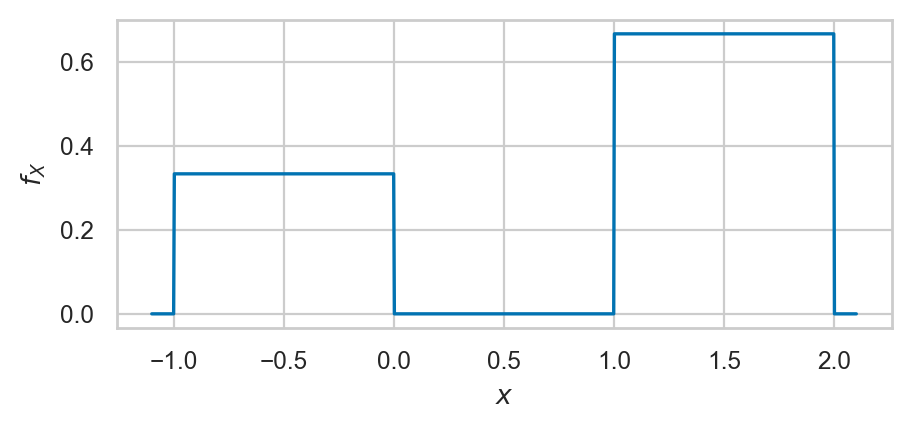

In [44]:
# @solution
# a)
from ministats import plot_pdf
plot_pdf(rvX, xlims=[-1.1, 2.1]);

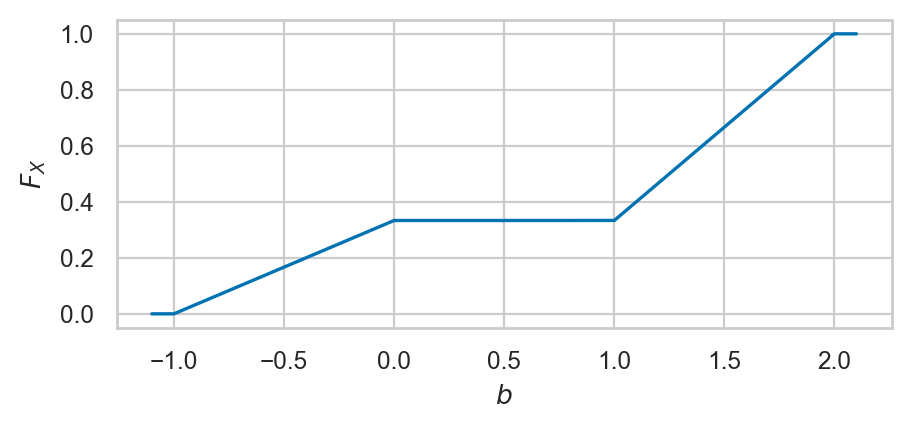

In [45]:
# @solution
# c)
# Suppress only the IntegrationWarning
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings("ignore", category=IntegrationWarning)

from ministats import plot_cdf
plot_cdf(rvX, xlims=[-1.1, 2.1]);

In [46]:
# @solution
# d)
from scipy.integrate import quad

# Pr({-1/2 <= X <= 0})
quad(rvX.pdf, a=-1/2, b=0)[0]

0.16666666666666666

In [47]:
# @solution
# Pr({1 <= X <= 3/2})
quad(rvX.pdf, a=1, b=3/2)[0]

0.3333333333333333

In [48]:
# @solution
# Pr({0 <= X <= 1})
quad(rvX.pdf, a=0, b=1)[0]

0.0

### P2.35
<!-- {prob:alt-formula-for-covXY} -->

Prove that the alternative formula $\mathbf{Cov}(X,Y) = \mathbb{E}_{XY}[XY] - \mu_X\mu_Y$
correctly computes the covariance between the random variables $X$ and $Y$.

Hint: Start with the definition of $\mathbf{Cov}(X,Y)$ and simplify the expression.


<!-- @solution -->
**Solution** 
We start with the definition of covariance and proceed to expand the parentheses:
$$\begin{aligned}
                \mathbf{Cov}(X,Y)   &= \mathbb{E}_{XY}\!\left[(X - \mu_X)(Y - \mu_Y)\right]                        \\
                            &= \mathbb{E}_{XY}[XY - X\mu_Y - Y \mu_X + \mu_X\mu_Y]                 \\
                            &= \mathbb{E}_{XY}[XY] - \mathbb{E}_{XY}[X]\mu_Y - \mathbb{E}_{XY}[Y] \mu_X + \mu_X\mu_Y \\
                            &= \mathbb{E}_{XY}[XY] - \mathbb{E}_{X}[X]\mu_Y - \mathbb{E}_{Y}[Y] \mu_X + \mu_X\mu_Y   \\
                            &= \mathbb{E}_{XY}[XY] - \mu_X\mu_Y - \mu_Y\mu_X + \mu_X\mu_Y              \\
                            &= \mathbb{E}_{XY}[XY] - \mu_X\mu_Y.
\end{aligned}$$
The above calculations used the linear property of expectations
and the definitions of the marginal means $\mu_X = \mathbb{E}_{X}[X]$ and $\mu_Y = \mathbb{E}_{Y}[Y]$.

### P2.36
<!-- {prob:de-morgan-and-complent-rule} -->
Consider some events $A$ and $B$ and their complements $A^c$ and $B^c$.
We're interested in computing the probability of the union $A \cup B$,
which corresponds to an outcome that is either in $A$ or in $B$,
or in both.
*De Morgan's law* in set theory tells us that $(A \cup B)^c = A^c \cap B^c$.
Combining De Morgan's law with the complement rule of probability
gives us the following formula:
$$\textrm{Pr}(A \cup B) = 1 - \textrm{Pr}(A^c \cap B^c),$$
which tells us that we can compute the probability of the union of two events
as the complement of the intersection of their complements.
Check that this formula is valid for the events $A = \{1,2,3\}$ and $B = \{2,3,4\}$
of the die roll random variable $D$
by computing the probabilities in the above equation.

In [49]:
# @studentprompt
# Define the sets and their complements
A = {1,2,3}
B = {2,3,4}
calD = {1,2,3,4,5,6}  # sample space of D
Ac = calD.difference(A)
Bc = calD.difference(B)

# Function that calculates the probability of event E (a set)
def Pr(E):
    return sum([1/6 for outcome in E])

# Compute the left and right sides of the equation
...

Ellipsis

In [50]:
# @solution
# Define the sets and their complements
A = {1,2,3}
B = {2,3,4}
calD = {1,2,3,4,5,6}  # sample space of D
Ac = calD.difference(A)
Bc = calD.difference(B)

# Function that calculates the probability of event E (a set)
def Pr(E):
    return sum([1/6 for outcome in E])

# Compute the left and right sides of the equation
Pr(A.union(B)), 1 - Pr(Ac.intersection(Bc))

(0.6666666666666666, 0.6666666666666667)

<!-- @solution -->
**Solution** 
For the die roll random variable $D$, the sample space is $\mathcal{D} = \{1,2,3,4,5,6\}$.
We're given the sets $A = \{1,2,3\}$ and $B = \{2,3,4\}$.
Their complements are $A^c = \{4,5,6\}$ and $B^c = \{1,5,6\}$.
Their union is $A \cup B = \{1,2,3,4\}$.
The intersection of their complements is $A^c \cap B^c = \{5,6\}$.
To verify the formula $\textrm{Pr}(A \cup B) = 1 - \textrm{Pr}(A^c \cap B^c)$,
we compute the probabilities $\textrm{Pr}(A \cup B) = \textrm{Pr}(\{1,2,3,4\}) = \tfrac{4}{6}$
and $\textrm{Pr}(A^c \cap B^c) = \textrm{Pr}(\{5,6\}) = \tfrac{2}{6}$,
then plug in these values to get $\tfrac{4}{6} = 1- \tfrac{2}{6}$,
which verifies that the formula works in this case.